In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.sparse.linalg import eigsh
import mosek
from tqdm import tqdm

from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

import random
from sympy import Matrix
import cvxpy as cp

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],   # default LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 15, 
})

In [3]:
# Parameters 

L = 8 # Length of the chain / Number of sites
N = 3**L # Total number of pulses
I = L-1 # Number of hopping terms (per spin)
R = I # Number of rows / total hopping terms
ratio = 5 # Column to row ratio
K = ratio*R # Number of pulses (columns) to be considered

In [4]:
def one_dim_chain_row_labels(I,L):
    rows  = np.zeros(shape = (I,L) , dtype=np.float64)
    
    for i in range(I):
        for j in range(L):
            if rows[i][i+j] == 0 and rows[i][i+j+1] == 0:
                rows[i][i+j] = 1
                rows[i][i+j+1] = 2
            else:
                break
    return rows

rows = one_dim_chain_row_labels(I,L)
rows

array([[1., 2., 0., 0., 0., 0., 0., 0.],
       [0., 1., 2., 0., 0., 0., 0., 0.],
       [0., 0., 1., 2., 0., 0., 0., 0.],
       [0., 0., 0., 1., 2., 0., 0., 0.],
       [0., 0., 0., 0., 1., 2., 0., 0.],
       [0., 0., 0., 0., 0., 1., 2., 0.],
       [0., 0., 0., 0., 0., 0., 1., 2.]])

In [5]:
#------------------------------------------------------------------------------------------------
# Function which takes a number between 0 and N-1 and converts it to a base 3 array

def tritarray(x,M):
    tritarray = np.zeros(shape = M)
    for j in range(M):
        r = x % 3
        x = x // 3 
        tritarray[-(j+1)] = r
    return tritarray
#------------------------------------------------------------------------------------------------
# Function for selecting K random pulses on M modes

def random_pulses(M,K):
    
    N = 3**M
    
    sample = random.sample(range(N),K) 
    pulses = np.zeros(shape = (K,M)) # K pulses of length M
    
    for j in range(K):
        pulses[j] = tritarray(sample[j],M)
        
    return pulses

def all_pulses(M):
    N = 3**M
    
    pulses = np.zeros(shape = (N,M))

    for j in range(N):
        pulses[j] = tritarray(j,M)
    
    return pulses

In [6]:
#------------------------------------------------------------------------------------------------
# Function for finding the constraint matrix with random pulses (should work on other geometries)

def constraint_matrix_random_pulses(L,K,rows):

    I = int((L-1)) 
    R = I
    M = L
    pulses = random_pulses(M,K)
    F = np.zeros(shape = (R,K), dtype=np.complex128)
    w = np.exp(1j*2*np.pi/3)

    for i in range(R):
        for j in range(K):
            power = rows[i]@pulses[j]
            F[i][j] = w**power

    return F,pulses
#------------------------------------------------------------------------------------------------
# Function for finding the constraint matrix with given pulses (should work on other geometries)

def constraint_matrix_given_pulses(L,K,spinful_rows,pulses):

    I = int((L-1)) 
    R = I
    F = np.zeros(shape = (R,K), dtype=np.complex128)
    w = np.exp(1j*2*np.pi/3)

    for i in range(R):
        for j in range(K):
            power = spinful_rows[i]@pulses[j]
            F[i][j] = w**power

    return F

#------------------------------------------------------------------------------------------------
# Check if F is feasible
def check_feasible(F):

    x = cp.Variable(F.shape[1])
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == 0, x >= 1]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    LP_has_solution = 0
    F_has_full_rank = 0
    
    if type(x.value) == np.ndarray:
        LP_has_solution = 1
    if F.shape[0]- np.linalg.matrix_rank(F)==0:
        F_has_full_rank = 1
    feasible = LP_has_solution * F_has_full_rank
    
    return bool(feasible)
#------------------------------------------------------------------------------------------------
# Random target Hamiltonian coefficients

def random_hamiltonian_coef(R, magnitude=1):
    # uniform angle
    theta = 2 * np.pi * np.random.rand(R)
    # radius distributed as sqrt of uniform to get uniform area measure
    r = magnitude * np.sqrt(np.random.rand(R))
    return r * np.exp(1j * theta)
#------------------------------------------------------------------------------------------------

def hamiltonian_engineering(L,K,spinful_rows,pulses,beta):

    F = constraint_matrix_given_pulses(L,K,spinful_rows,pulses)


    x = cp.Variable(K)
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == beta, x>=0]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    return problem.value, x.value


In [25]:
def qtimes(ratio=5,M=40,shots=100):
    modes = np.arange(10,M,dtype=int)

    q_times = [[] for _ in range(len(modes))]

    for j in tqdm(range(len(modes))):
        x = 0
        while x<shots:
            L = modes[j]
            R = L-1
            K = ratio*R
            
            rows = one_dim_chain_row_labels(R,L)
            pulses = random_pulses(L,K)
            
            F = constraint_matrix_given_pulses(L,K,rows,pulses)
            feasible = check_feasible(F)
            
            if feasible ==True:
                beta = random_hamiltonian_coef(L-1)
                q_time = hamiltonian_engineering(L,K,rows,pulses,beta)[0]
                q_times[j].append(q_time)
            x += 1
        q_times[j] = np.array(q_times[j])

    return q_times



In [26]:
q_times6 = qtimes(ratio=6)


100%|██████████| 30/30 [01:06<00:00,  2.23s/it]


In [27]:
q_times7 = qtimes(ratio=7)

100%|██████████| 30/30 [01:20<00:00,  2.70s/it]


In [28]:
q_times8 = qtimes(ratio=8)

100%|██████████| 30/30 [01:30<00:00,  3.01s/it]


In [29]:
q_times9 = qtimes(ratio=9)

100%|██████████| 30/30 [01:41<00:00,  3.38s/it]


In [32]:
modes = np.arange(10,40,dtype=int)

means6 = np.array([x.mean() for x in q_times6])
stds6  = np.array([x.std(ddof=1) for x in q_times6])  # ddof=1 = sample std (usually right for error bars)
sems6 = stds6 / np.sqrt(np.array([len(x) for x in q_times6]))

means7 = np.array([x.mean() for x in q_times7])
stds7  = np.array([x.std(ddof=1) for x in q_times7])  # ddof=1 = sample std (usually right for error bars)
sems7 = stds7 / np.sqrt(np.array([len(x) for x in q_times7]))

means8 = np.array([x.mean() for x in q_times8])
stds8  = np.array([x.std(ddof=1) for x in q_times8])  # ddof=1 = sample std (usually right for error bars)
sems8 = stds8 / np.sqrt(np.array([len(x) for x in q_times8]))

means9 = np.array([x.mean() for x in q_times9])
stds9  = np.array([x.std(ddof=1) for x in q_times9])  # ddof=1 = sample std (usually right for error bars)
sems9 = stds9 / np.sqrt(np.array([len(x) for x in q_times9]))


cmap = plt.get_cmap("bone")
colors = cmap(np.linspace(0.6, 0.1, 4))  

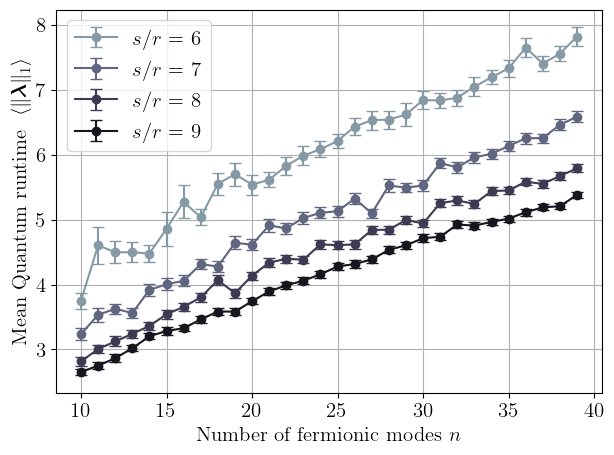

In [33]:
plt.figure()

plt.errorbar(modes, means6, yerr=sems6, fmt='o-', capsize=4,color = colors[0], label ='$s/r$ = 6')
plt.errorbar(modes, means7, yerr=sems7, fmt='o-', capsize=4,color = colors[1], label = '$s/r$ = 7')
plt.errorbar(modes, means8, yerr=sems8, fmt='o-', capsize=4,color = colors[2], label = '$s/r$ = 8')
plt.errorbar(modes, means9, yerr=sems9, fmt='o-', capsize=4,color = colors[3], label = '$s/r$ = 9')


plt.xlabel(r"Number of fermionic modes\ $n$")
plt.ylabel(r"Mean Quantum runtime \ $\langle\|\boldsymbol{\lambda}\|_1\rangle$")
plt.tight_layout()
plt.legend()
plt.grid()
plt.savefig("trade_off.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')
plt.show()